In [1]:
import numpy as np
import scipy as sp

In [2]:
def qp_admm(Sigma, A, b, rho, reg, max_iter, distribution, random_P, p):
    n = A.shape[1]
    m = A.shape[0]
    costs = np.zeros( shape = (max_iter,1) )

    z = np.random.normal( size = (n, 1) )
    x = np.random.normal( size = (n, 1) )
    u = np.zeros( shape = (n, 1) )
    Sigma_decomp = sp.sparse.linalg.splu(rho * Sigma + np.eye(n))

    for iter in range(max_iter):
        if(random_P == True):
            p = np.random.randint(low = 1, high = m + 1)
        if(distribution == 'g'):
            # normal random
            S = np.random.normal( size = (p, m) )
        elif(distribution == 'u'):
            # uniform random
            S = np.random.uniform(low = 0, high = 1, size = (p, m) )
        else:
            # block sample
            ind = np.random.choice(m, p, replace = False)
            S = np.eye(m)
            S = S[ind, :]
        
        A_sketch = A

        x = Sigma_decomp.solve(z - u)

        z = (x + u) + A_sketch.T @ np.linalg.lstsq(A_sketch @ A_sketch.T + reg * np.eye(m), b - A_sketch @ (x + u))[0]
        u = x - z + u

        costs[iter] = x.T @ Sigma @ x
    return costs, x

In [3]:
n = 100
max_iter = 1000
admm_lambda = 1

In [4]:
rng = np.random.default_rng(4)
mu = rng.standard_normal(size=(1, n)) + 1
r = rng.standard_normal() + 1
Sigma = rng.standard_normal(size=(n, n))
A = np.concatenate( (mu, np.ones((1,n))) , axis = 0)
b = np.array([[r],[1]])

Sigma = Sigma.T @ Sigma

In [5]:
np.linalg.cond(Sigma)

252618.71547410032

In [6]:
costs, sol = qp_admm(Sigma, A, b, rho=1, reg=1, max_iter=1000, distribution='g', random_P=False, p=1)

/var/folders/tw/zng4qsks70qffqd19hxk_1hr0000gn/T/ipykernel_67950/2375230282.py:9: SparseEfficiencyWarning: splu converted its input to CSC format
  Sigma_decomp = sp.sparse.linalg.splu(rho * Sigma + np.eye(n))
/var/folders/tw/zng4qsks70qffqd19hxk_1hr0000gn/T/ipykernel_67950/2375230282.py:30: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  z = (x + u) + A_sketch.T @ np.linalg.lstsq(A_sketch @ A_sketch.T + reg * np.eye(m), b - A_sketch @ (x + u))[0]


In [7]:
import cvxpy as cvx

x = cvx.Variable( (n,1) )
cost = cvx.quad_form(x, Sigma, assume_PSD = True)
constraints = [mu @ x == r, cvx.sum(x) == 1]
prob = cvx.Problem(cvx.Minimize(cost), constraints)
prob.solve()

costs = costs - cost.value

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


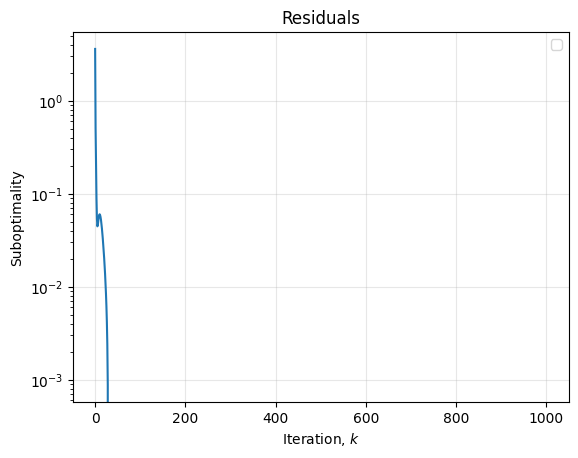

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
plt.semilogy(np.arange(max_iter), costs)
# ax.set_xticks(np.arange(max_iter))
plt.xlabel('Iteration, $k$')
plt.ylabel('Suboptimality')
plt.title('Residuals')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()